# **CHAPTER 7: Ensemble Learning and Random Forests**


This majority-vote classifier is called a hard voting classifier


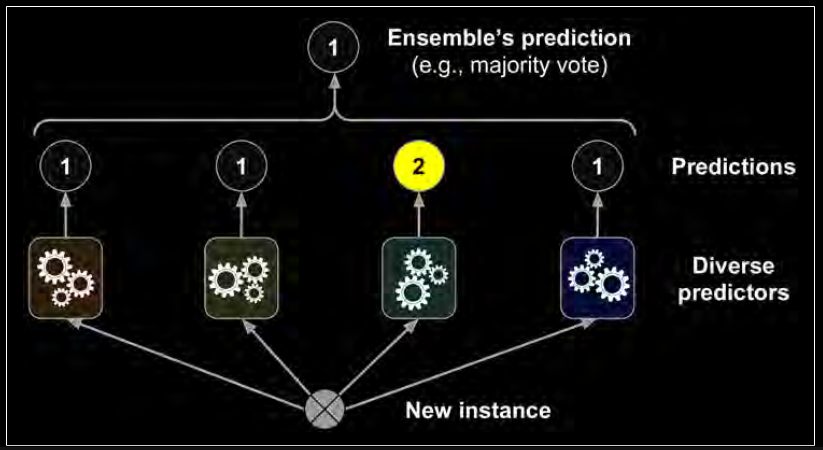

# **Voting Classifiers**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"/home/noneo/Codes/ML/MachineLearning/Datasets/scaling-data1.csv")
df

,age,salary,target
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [18]:
df.isna().sum()

age       0
salary    0
target    0
dtype: int64

In [19]:
df.describe()

,age,salary,target
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [20]:
X = df.drop('target', axis=1)
y = df['target']

In [21]:
y.value_counts()

target
0    257
1    143
Name: count, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC()

voting_clf = VotingClassifier(
    estimators=[("log", log_clf),("rf", rnd_clf), ("svc", svm_clf)],
    voting="hard"
)

voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('log', LogisticRegression()),
                             ('rf', RandomForestClassifier()), ('svc', SVC())])

In [26]:
from sklearn.metrics import accuracy_score
p = []

for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))
    p.append(y_pred)
    

LogisticRegression 0.8875
RandomForestClassifier 0.875
SVC 0.7375
VotingClassifier 0.85


## **Bagging and Pasting:**

In [27]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    max_samples=100, bootstrap=True, n_jobs=-1
)

bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

In [28]:
y_pred

array([1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0])

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

tree_clf = DecisionTreeClassifier()
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=500,
    max_samples=100,
    bootstrap=True,
    n_jobs=-1
)

tree_clf.fit(X_train, y_train)
bag_clf.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=100,
                  n_estimators=500, n_jobs=-1)

In [32]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [37]:
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap



x1_min, x1_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
x2_min, x2_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, 1),
    np.arange(x2_min, x2_max, 1000)
)

X_grid = np.c_[xx1.ravel(), xx2.ravel()]

/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but BaggingClassifier was fitted with feature names
  warnings.warn(


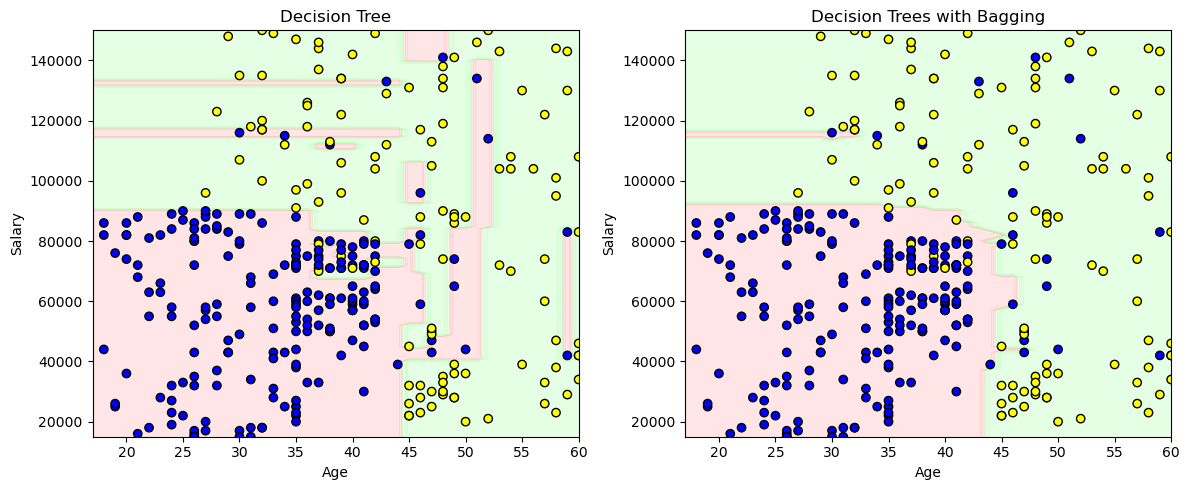

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = [tree_clf, bag_clf]
titles = ["Decision Tree", "Decision Trees with Bagging"]

for i, model in enumerate(models):
    Z = model.predict(X_grid).reshape(xx1.shape)

    axes[i].contourf(xx1, xx2, Z, alpha=0.3, cmap=ListedColormap(["#FFAAAA", "#AAFFAA"]))
    
    axes[i].scatter(
    X_train.iloc[:, 0],
    X_train.iloc[:, 1],
    c=y_train,
    cmap=ListedColormap(["blue", "yellow"]),
    edgecolor="k"
)

    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Age")
    axes[i].set_ylabel("Salary")

plt.tight_layout()
plt.show()

In [38]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), n_estimators=500,
    bootstrap=True, n_jobs=-1, oob_score=True
    )

bag_clf.fit(X_train, y_train)

bag_clf.oob_score_

0.875

In [39]:
# from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.8875

In [40]:
bag_clf.oob_decision_function_

array([[1.        , 0.        ],
       [0.        , 1.        ],
       [0.02298851, 0.97701149],
       [0.18848168, 0.81151832],
       [0.        , 1.        ],
       [0.10067682, 0.89932318],
       [1.        , 0.        ],
       [0.59042553, 0.40957447],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.078125  , 0.921875  ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.65816327, 0.34183673],
       [1.        , 0.        ],
       [0.60406091, 0.39593909],
       [0.1091954 , 0.8908046 ],
       [0.93617021, 0.06382979],
       [0.11398964, 0.88601036],
       [0.76966292, 0.23033708],
       [0.05208333, 0.94791667],
       [0.87283237, 0.12716763],
       [0.00549451, 0.99450549],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.00857843, 0.99142157],
       [0.        , 1.        ],
       [0.16796875, 0.83203125],
       [0.00578035, 0.99421965],
       [1.        , 0.        ],
       [1.

# **Random Patches and Random Subspaces**

The BaggingClassifier class supports sampling the features as well. This is con‐
trolled by two hyperparameters: max_features and bootstrap_features.

when you are dealing with high-dimensional inputs.Sampling both training instances and features is called the Random patches method. Keeping all training instances (i.e., bootstrap=False and max_samples=1.0) but sampling features (i.e., bootstrap_features=True and/or max_features smaller than 1.0) is called the Random Subspaces method.



# **Random Forests**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1)
rnd_clf.fit(X_train, y_train)
y_pred_rf = rnd_clf.predict(X_test)


In [ ]:
accuracy_score(y_test, y_pred_rf)

0.925

In [43]:
bag_clf = BaggingClassifier(
DecisionTreeClassifier(splitter="random", max_leaf_nodes=16),
n_estimators=500, max_samples=1.0, bootstrap=True, n_jobs=-1
)

In [44]:
from sklearn.datasets import load_iris

iris  = load_iris()
rnd_clf = RandomForestClassifier(n_estimators=500, n_jobs=-1)
rnd_clf.fit(iris['data'], iris['target'])
for name, score in zip(iris['feature_names'],rnd_clf.feature_importances_):
    print(name, score)


sepal length (cm) 0.08885300483374665
sepal width (cm) 0.021056007710381165
petal length (cm) 0.4585886683145158
petal width (cm) 0.43150231914135645


# **AdaBoost**

In [48]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=2), 
    n_estimators=200,
    learning_rate=0.5
)

ada_clf.fit(X_train, y_train)

/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                   learning_rate=0.5, n_estimators=200)

In [49]:
y_pred_ada = ada_clf.predict(X_test)
accuracy_score(y_test, y_pred_ada)

0.85

# **Gradient Boosting:**

In [50]:
from sklearn.tree import DecisionTreeRegressor

tree_reg1 = DecisionTreeRegressor(max_depth=2)
tree_reg1.fit(X, y)

y2 = y - tree_reg1.predict(X)

print(y2)

0     -0.037344
1     -0.037344
2     -0.037344
3     -0.037344
4     -0.037344
         ...   
395    0.333333
396    0.109890
397    0.109890
398   -0.037344
399    0.109890
Name: target, Length: 400, dtype: float64


In [52]:
tree_reg2 = DecisionTreeRegressor(max_depth=2)
tree_reg2.fit(X, y2)
y3 = y2 - tree_reg2.predict(X)
print(y3)

0      0.019230
1      0.019230
2      0.019230
3      0.019230
4      0.019230
         ...   
395    0.343042
396    0.119599
397    0.119599
398   -0.114061
399    0.119599
Name: target, Length: 400, dtype: float64


In [70]:
tree_reg3 = DecisionTreeRegressor(max_depth=2)
tree_reg3.fit(X, y3)

X_new = np.array([
    [0.5, 1.2],
    [1.0, 2.0],
    [3.0, 4.0],
    [5, 5]
])
y_pred = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [71]:
y_pred

array([-0.00816069, -0.00816069, -0.00816069, -0.00816069])

Same

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=3, learning_rate=1.0)
gbrt.fit(X, y)


GradientBoostingRegressor(learning_rate=1.0, max_depth=2, n_estimators=3)

In [74]:
y_pred = gbrt.predict(X_new)
y_pred

/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


array([-0.00816069, -0.00816069, -0.00816069, -0.00816069])

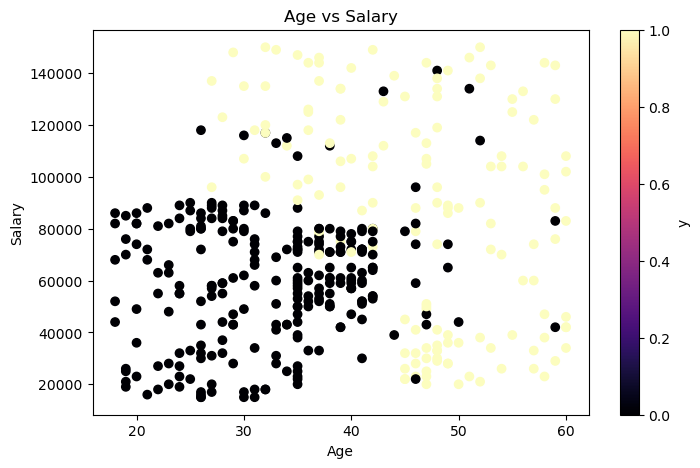

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(X['age'], X['salary'], c=y, cmap='magma')
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")
plt.colorbar(label='y')

plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=120)
gbrt.fit(X_train, y_train)

errors = [mean_squared_error(y_test, y_pred) for y_pred in gbrt.staged_predict(X_test)] 

bst_n_estimators = np.argmin(errors)

gbrt_best = GradientBoostingRegressor(max_depth=2,n_estimators=bst_n_estimators)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=33)

In [86]:
bst_n_estimators

33

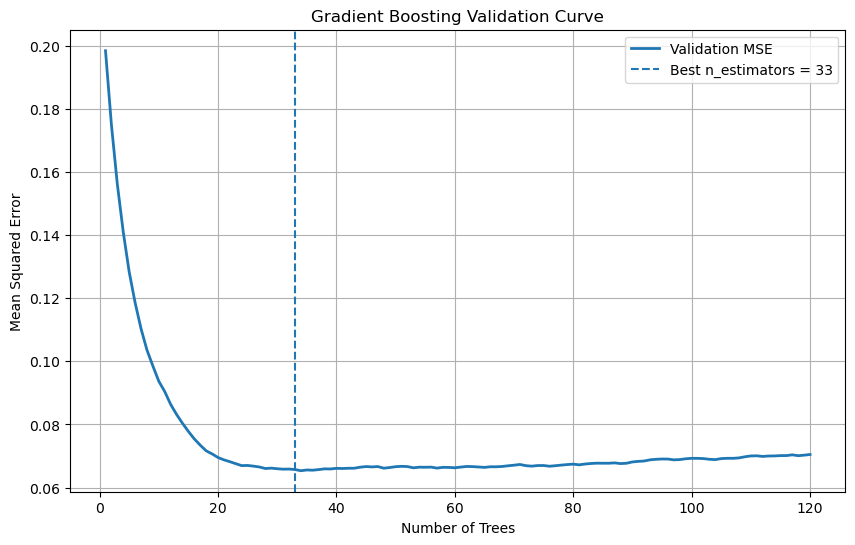

In [ ]:

plt.figure(figsize=(10, 6))

plt.plot( range(1, len(errors) + 1), errors, linewidth=2, label="Validation MSE")
plt.axvline(bst_n_estimators, linestyle="--", label=f"Best n_estimators = {bst_n_estimators}")

plt.xlabel("Number of Trees")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Boosting Validation Curve")
plt.legend()
plt.grid(True)

plt.show()

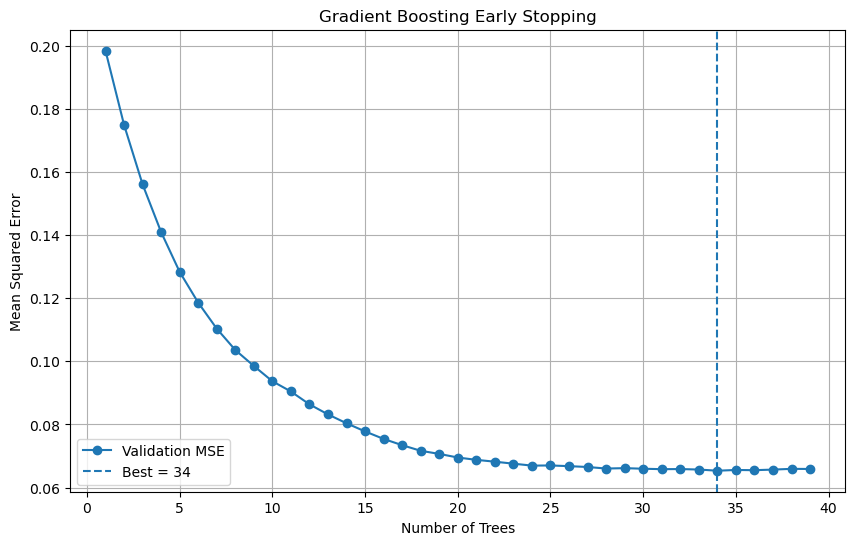

Best n_estimators: 34
Minimum validation error: 0.06533581690095465


In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

gbrt = GradientBoostingRegressor(max_depth=2, warm_start=True, random_state=42)

min_val_error = float("inf")
error_going_up = 0

val_errors = []
n_trees = []

for n_estimators in range(1, 120):
    gbrt.n_estimators = n_estimators
    gbrt.fit(X_train, y_train)

    y_pred = gbrt.predict(X_test)
    val_error = mean_squared_error(y_test, y_pred)

    val_errors.append(val_error)
    n_trees.append(n_estimators)

    if val_error < min_val_error:
        min_val_error = val_error
        best_n_estimators = n_estimators
        error_going_up = 0
    else:
        error_going_up += 1

        if error_going_up == 5:
            break

plt.figure(figsize=(10, 6))
plt.plot(n_trees, val_errors, marker='o', label='Validation MSE')

plt.axvline(best_n_estimators, linestyle='--', label=f'Best = {best_n_estimators}')
plt.xlabel("Number of Trees")
plt.ylabel("Mean Squared Error")
plt.title("Gradient Boosting Early Stopping")
plt.legend()
plt.grid(True)

plt.show()

print("Best n_estimators:", best_n_estimators)
print("Minimum validation error:", min_val_error)

# **Stacking:**

In [93]:
!pip install deslib

### **you can use an open source implementation such as:** [deslib](https://github.com/Menelau/DESlib)

In [97]:
# Split training data into TRAIN and DSEL
X_train2, X_dsel, y_train2, y_dsel = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42
)

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pool_classifiers = [
    DecisionTreeClassifier(max_depth=1),
    DecisionTreeClassifier(max_depth=2),
    DecisionTreeClassifier(max_depth=3),
    RandomForestClassifier(n_estimators=10, max_depth=3)
]


In [105]:
from deslib.des.knora_e import KNORAE

for clf in pool_classifiers:
    clf.fit(X_train, y_train)
    
    knorae = KNORAE(pool_classifiers)

knorae.fit(X_dsel, y_dsel)

y_pred = knorae.predict(X_test)

/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/noneo/miniconda3/envs/aienv/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fit

In [106]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9125


In [107]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))


[[47  5]
 [ 2 26]]
              precision    recall  f1-score   support

           0       0.96      0.90      0.93        52
           1       0.84      0.93      0.88        28

    accuracy                           0.91        80
   macro avg       0.90      0.92      0.91        80
weighted avg       0.92      0.91      0.91        80



```
8. Load the MNIST data (introduced in Chapter 3), and split it into a training set, a validation set, and a test set (e.g., use the first 40,000 instances for training, the next 10,000 for validation, and the last 10,000 for testing). Then train various classifiers, such as a Random Forest classifier, an Extra-Trees classifier, and an SVM. Next, try to combine them into an ensemble that outperforms them all on the validation set, using a soft or hard voting classifier. Once you have found one, try it on the test set. How much better does it perform compared to the individual classifiers?
```





```
9. Run the individual classifiers from the previous exercise to make predictions on the validation set, and create a new training set with the resulting predictions: each training instance is a vector containing the set of predictions from all your classifiers for an image, and the target is the image’s class. Congratulations, you have just trained a blender, and together with the classifiers they form a stacking ensemble! Now let’s evaluate the ensemble on the test set. For each image in the test set, make predictions with all your classifiers, then feed the predictions to the blender to get the ensemble’s predictions. How does it compare to the voting classifier you trained earlier?
```